# 부서별 요청사항 라우팅 분류기
**유형:** 다중 클래스 분류형 (임베딩 + SVM/로지스틱 회귀 비교)  
**목표:** IT 헬프데스크 요청을 입력하면 담당 부서(카테고리)를 자동 분류하는 AI 만들기

---
### 데이터 출처
- **한국어 IT 헬프데스크 데이터** (20,000건) — 5개 카테고리, 15개 서브카테고리
- 조합형 템플릿 기반으로 생성된 다양한 IT 문의 텍스트

### 라벨 정의
| 라벨 | 의미 | 데이터 비율 |
|------|------|-------------|
| Hardware | 하드웨어 관련 문의 (CPU, 모니터, 마우스, 키보드, 디스크) | ~25% |
| Software | 소프트웨어 관련 문의 (OS, 이메일, 사내 앱) | ~24% |
| Inquiry/Help | 일반 문의/도움 요청 (백신, 이메일 관련) | ~23% |
| Network | 네트워크 관련 문의 (VPN, 무선, DHCP) | ~16% |
| Database | 데이터베이스 관련 문의 (Oracle, MS SQL, DB2) | ~12% |

### 이 노트북의 구조
| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 및 탐색 |
| Step 2 | 데이터 전처리 |
| Step 3 | 임베딩 & 분류기 학습 (모델 비교) |
| Step 4 | 예측 & 평가 |
| Step 5 | 미니 미션 |

### 왜 IT 헬프데스크 요청 분류가 중요한가?
IT 헬프데스크에는 매일 수백~수천 건의 요청이 접수됩니다:
- 사람이 직접 읽고 담당 부서를 배정하는 것은 시간 낭비이고 실수 가능성이 높음
- 자동 분류로 **즉시 담당 부서 배정**, **응답 시간 단축**, **업무 효율화** 가능
- 5개 부서로의 라우팅을 자동화하여 **IT 운영 비용 절감** 효과

## Step 1: 데이터 로드 및 탐색

In [1]:
# =============================================================================
# 1. 필수 라이브러리 설치 및 임포트
# =============================================================================
# [의도] 이 프로젝트에서 사용하는 모든 외부 라이브러리를 설치하고 불러옵니다.
#   - sentence-transformers: 텍스트를 고차원 벡터(임베딩)로 변환하는 사전학습 모델 라이브러리
#   - scikit-learn: 분류기(LogisticRegression, SVM) 학습 및 성능 평가 도구
#   - torch: sentence-transformers의 내부 연산을 위한 딥러닝 프레임워크(PyTorch)
# =============================================================================
!pip install sentence-transformers scikit-learn torch

# re: 텍스트 전처리 시 정규표현식으로 노이즈를 제거하기 위해 사용
import re

# pandas: 표 형태의 데이터(DataFrame)를 다루기 위한 핵심 라이브러리
# numpy: 임베딩 벡터 등 수치 배열 연산에 사용
import pandas as pd
import numpy as np

# Counter: 텍스트 중복 빈도를 세어 데이터 품질을 확인할 때 사용
from collections import Counter

In [2]:
# =============================================================================
# 2. IT 헬프데스크 데이터 로드 (CSV -> DataFrame)
# =============================================================================
# [의도] 사전에 생성한 korean_it_helpdesk_20000_with_5labels_v2.csv를 로드하여
# 기본 분포를 확인합니다.
#
# [데이터 구조]
#   - Category: 대분류 라벨 (Hardware, Software, Inquiry/Help, Network, Database)
#   - Subcategory: 세부 분류 (CPU, Monitor, VPN, Oracle 등 15개)
#   - Text: IT 문의 텍스트 (한국어)
#   - urgency, sentiment, intent, product, tech_level: 부가 속성
#
# [이 노트북에서 사용할 컬럼]
#   - Text: 입력 텍스트 (임베딩 대상)
#   - Category: 분류 라벨 (5개 부서로 라우팅)
# =============================================================================
raw_df = pd.read_csv("./Data/korean_it_helpdesk_20000_with_5labels_v2.csv")

print(f"전체 데이터: {len(raw_df):,}건\n")

# 카테고리별 분포: 5개 부서에 요청이 얼마나 분배되어 있는지 확인합니다.
print("=== 카테고리별 분포 ===")
cat_counts = raw_df["Category"].value_counts()
for cat, cnt in cat_counts.items():
    print(f"  {cat:15s}: {cnt:,}건 ({cnt/len(raw_df)*100:.1f}%)")

# 서브카테고리별 분포: 세부 항목의 분포를 확인합니다.
print(f"\n=== 서브카테고리별 분포 (상위 10개) ===")
sub_counts = raw_df["Subcategory"].value_counts().head(10)
for sub, cnt in sub_counts.items():
    print(f"  {sub:25s}: {cnt:,}건")

# 교차표: 카테고리별 서브카테고리 구성을 확인합니다.
print(f"\n=== 카테고리 x 서브카테고리 교차표 ===")
print(pd.crosstab(raw_df["Category"], raw_df["Subcategory"]))

전체 데이터: 20,000건

=== 카테고리별 분포 ===
  Hardware       : 5,082건 (25.4%)
  Software       : 4,703건 (23.5%)
  Inquiry/Help   : 4,526건 (22.6%)
  Network        : 3,269건 (16.3%)
  Database       : 2,420건 (12.1%)

=== 서브카테고리별 분포 (상위 10개) ===
  Antivirus                : 2,780건
  Email                    : 2,595건
  Operating System         : 2,108건
  Internal Application     : 1,746건
  Wireless                 : 1,325건
  Disk                     : 1,197건
  VPN                      : 1,172건
  CPU                      : 1,146건
  MS SQL Server            : 968건
  Monitor                  : 950건

=== 카테고리 x 서브카테고리 교차표 ===
Subcategory   Antivirus   CPU  DB2  DHCP  Disk  Email  Internal Application  \
Category                                                                      
Database              0     0  655     0     0      0                     0   
Hardware              0  1146    0     0  1197      0                     0   
Inquiry/Help       2780     0    0     0     0      0               

In [3]:
# =============================================================================
# 3. 원본 데이터 품질 확인 (전처리 전)
# =============================================================================
# [의도] 전처리를 적용하기 전에 원본 데이터의 품질 문제를 파악합니다.
# 이 분석 결과를 바탕으로 다음 셀에서 어떤 전처리를 적용할지 결정합니다.
# 확인하는 항목:
#   1) 텍스트 길이 분포: 너무 짧은 텍스트는 분류 단서가 부족
#   2) 10자 미만 텍스트: IT 문의의 맥락을 파악하기 어려운 극히 짧은 텍스트
#   3) 중복 텍스트: 동일 문의가 반복되면 학습 데이터의 다양성이 감소
#   4) 카테고리별 텍스트 특성: 부서별 문의 스타일 차이
# =============================================================================
print("=== 원본 데이터 품질 분석 ===\n")

# 텍스트 길이 통계: 문의의 전반적인 길이 분포를 파악합니다.
lengths = raw_df["Text"].astype(str).str.len()
print(f"텍스트 길이 통계:")
print(f"  평균: {lengths.mean():.0f}자, 중앙값: {lengths.median():.0f}자")
print(f"  최소: {lengths.min()}자, 최대: {lengths.max()}자")

# 10자 미만 텍스트: IT 문의의 맥락을 파악할 수 없는 극히 짧은 텍스트
# 이러한 텍스트는 전처리 단계에서 제거합니다.
short_mask = lengths < 10
print(f"\n10자 미만 텍스트: {short_mask.sum():,}건 ({short_mask.mean()*100:.1f}%)")
if short_mask.sum() > 0:
    print(f"  예시: {raw_df.loc[short_mask, 'Text'].head(5).tolist()}")

# 중복 텍스트: 가장 많이 반복되는 문의를 확인합니다.
# v2 데이터는 조합형 생성으로 100% 고유 텍스트를 목표로 합니다.
text_counter = Counter(raw_df["Text"].astype(str))
dup_count = sum(1 for cnt in text_counter.values() if cnt > 1)
print(f"\n중복 텍스트: {dup_count}건")
if dup_count > 0:
    print(f"  가장 빈번한 텍스트 (상위 5개):")
    for text, count in text_counter.most_common(5):
        if count > 1:
            print(f"  [{count}회] {text[:60]}{'...' if len(text) > 60 else ''}")

# 카테고리별 텍스트 길이: 부서별 문의 스타일 차이를 확인합니다.
print(f"\n=== 카테고리별 텍스트 길이 ===")
for cat in raw_df["Category"].unique():
    cat_lengths = raw_df[raw_df["Category"] == cat]["Text"].astype(str).str.len()
    print(f"  {cat:15s}: 평균 {cat_lengths.mean():.0f}자, 중앙값 {cat_lengths.median():.0f}자")

=== 원본 데이터 품질 분석 ===

텍스트 길이 통계:
  평균: 62자, 중앙값: 61자
  최소: 10자, 최대: 132자

10자 미만 텍스트: 0건 (0.0%)

중복 텍스트: 0건

=== 카테고리별 텍스트 길이 ===
  Hardware       : 평균 58자, 중앙값 56자
  Network        : 평균 64자, 중앙값 63자
  Inquiry/Help   : 평균 64자, 중앙값 63자
  Software       : 평균 62자, 중앙값 61자
  Database       : 평균 64자, 중앙값 63자


## Step 2: 데이터 전처리

IT 헬프데스크 문의 데이터는 조합형 템플릿으로 생성되었으므로 이커머스 리뷰와 다른 노이즈 특성을 가집니다:

| 문제 | 예시 | 해결 방법 |
|------|------|-----------|
| 불필요한 공백 | "프린터가  안 돼요" | strip + 다중 공백 제거 |
| 극히 짧은 텍스트 | "안 돼요" | 10자 미만 제거 |
| 완전 중복 | 동일 텍스트 반복 | drop_duplicates |

IT 문의 데이터는 사용자 직접 작성이 아닌 템플릿 기반이므로  
HTML 태그나 반복 문자(ㅋㅋㅋ)와 같은 이커머스 리뷰 특유의 노이즈가 없습니다.

In [4]:
# =============================================================================
# 4. 텍스트 전처리 함수 정의 + 데이터프레임 전처리
# =============================================================================
# [의도] IT 헬프데스크 문의에 특화된 텍스트 정제 규칙을 적용합니다.
#
# [이커머스 감성 분석기와의 차이점]
#   이커머스 리뷰에서는 HTML 태그, 반복 문자(ㅋㅋㅋ) 등의 노이즈가 많았지만,
#   IT 헬프데스크 문의는 템플릿 기반으로 생성되었으므로 비교적 깨끗합니다.
#   대신 공백 정리와 최소 길이 필터링에 집중합니다.
#
# [최소 길이 기준: 10자]
#   이커머스 리뷰는 5자, 고객문의 분류기는 15자였습니다.
#   IT 문의는 "프린터 안됨" 같은 짧은 문장도 의미가 있지만,
#   너무 짧으면 분류 단서가 부족하므로 10자로 설정합니다.
# =============================================================================

def clean_text(text):
    """
    IT 헬프데스크 문의 텍스트를 정제합니다.
    
    [처리 순서]
    1) 문자열 변환: NaN이나 숫자 등 비문자열 입력을 안전하게 처리
    2) 공백 정리: 다중 공백 -> 단일 공백, 앞뒤 공백 제거
    
    Args:
        text: 원본 문의 텍스트
    Returns:
        정제된 텍스트 문자열
    """
    # NaN이나 숫자 등 비문자열 입력을 문자열로 변환합니다.
    text = str(text)
    
    # 다중 공백 -> 단일 공백: "프린터가  안  돼요" -> "프린터가 안 돼요"
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


def preprocess_dataframe(df, min_length=10):
    """
    DataFrame 전체에 전처리를 적용합니다.
    
    [처리 순서]
    1) clean_text()를 모든 텍스트에 적용
    2) 빈 문자열 제거
    3) min_length 미만 텍스트 제거 (분류 단서 부족)
    4) 완전 중복 텍스트 제거 (과적합 방지)
    
    Args:
        df: Text, Category 컬럼이 있는 DataFrame
        min_length: 최소 텍스트 길이 (기본값 10)
    Returns:
        전처리된 DataFrame (원본은 변경하지 않음)
    """
    result = df.copy()
    original_len = len(result)
    
    # 모든 텍스트에 clean_text() 적용
    result["Text"] = result["Text"].apply(clean_text)
    
    # 빈 문자열 제거: clean_text 후 빈 문자열이 된 행을 제거합니다.
    result = result[result["Text"].str.len() > 0]
    print(f"  -> 빈 텍스트 제거 후: {len(result):,}건 (-{original_len - len(result)})")
    
    # 최소 길이 미만 제거: 분류에 필요한 최소한의 정보가 없는 텍스트를 제거합니다.
    before = len(result)
    result = result[result["Text"].str.len() >= min_length]
    print(f"  -> {min_length}자 미만 제거 후: {len(result):,}건 (-{before - len(result):,})")
    
    # 완전 중복 제거: 동일한 텍스트가 여러 번 있으면 첫 번째만 남깁니다.
    before = len(result)
    result = result.drop_duplicates(subset="Text", keep="first")
    print(f"  -> 중복 제거 후: {len(result):,}건 (-{before - len(result):,})")
    
    return result.reset_index(drop=True)


# 전처리 실행
print("데이터 전처리 중...")
print(f"  원본: {len(raw_df):,}건")
clean_df = preprocess_dataframe(raw_df, min_length=10)

데이터 전처리 중...
  원본: 20,000건
  -> 빈 텍스트 제거 후: 20,000건 (-0)
  -> 10자 미만 제거 후: 20,000건 (-0)
  -> 중복 제거 후: 20,000건 (-0)


In [5]:
# =============================================================================
# 5. 전처리 전후 비교
# =============================================================================
# [의도] 전처리가 데이터에 어떤 영향을 미쳤는지 확인합니다.
# 실제 텍스트 예시, 길이 변화, 카테고리 분포 변화를 비교하여
# 전처리가 적절하게 수행되었는지 검증합니다.
# =============================================================================
print("=== 전처리 전 vs 후 비교 ===\n")

# 원본 vs 정제된 텍스트 비교: 실제 전처리 효과를 확인합니다.
print("전처리 전 (원본):")
for _, row in raw_df.head(3).iterrows():
    print(f"  [{row['Category']}] {str(row['Text'])[:80]}...")

print(f"\n전처리 후 (정제):")
for _, row in clean_df.head(3).iterrows():
    print(f"  [{row['Category']}] {str(row['Text'])[:80]}...")

# 텍스트 길이 비교: 전처리로 텍스트가 얼마나 변했는지 확인합니다.
raw_lengths = raw_df["Text"].astype(str).str.len()
clean_lengths = clean_df["Text"].astype(str).str.len()
print(f"\n텍스트 길이 비교:")
print(f"  전처리 전 -- 평균: {raw_lengths.mean():.0f}자, 중앙값: {raw_lengths.median():.0f}자")
print(f"  전처리 후 -- 평균: {clean_lengths.mean():.0f}자, 중앙값: {clean_lengths.median():.0f}자")

# 카테고리 분포 변화: 전처리로 특정 카테고리의 데이터가 편향되게 제거되지 않았는지 확인합니다.
print(f"\n전처리 후 카테고리 분포:")
cat_dist = clean_df["Category"].value_counts()
for cat, cnt in cat_dist.items():
    print(f"  {cat:15s}: {cnt:,}건 ({cnt/len(clean_df)*100:.1f}%)")

=== 전처리 전 vs 후 비교 ===

전처리 전 (원본):
  [Hardware] PC가 뜨거워서 손을 못 대겠어습니다 사무실로 기사님 보내주실 수 있나습니다? 확인 부탁드리겠습니다....
  [Hardware] 모니터 케이블을 바꿔봤는데 모니터 하나만 인식돼요 모니터 자체 불량인가요. 같은 증상 세 번째인데 이번에 확실히 해결하고 싶어요....
  [Network] IP 주소가 169.254로 시작하는데 DHCP lease가 너무 빨리 만료돼요 ipconfig /release /renew 해봐도 안되요...

전처리 후 (정제):
  [Hardware] PC가 뜨거워서 손을 못 대겠어습니다 사무실로 기사님 보내주실 수 있나습니다? 확인 부탁드리겠습니다....
  [Hardware] 모니터 케이블을 바꿔봤는데 모니터 하나만 인식돼요 모니터 자체 불량인가요. 같은 증상 세 번째인데 이번에 확실히 해결하고 싶어요....
  [Network] IP 주소가 169.254로 시작하는데 DHCP lease가 너무 빨리 만료돼요 ipconfig /release /renew 해봐도 안되요...

텍스트 길이 비교:
  전처리 전 -- 평균: 62자, 중앙값: 61자
  전처리 후 -- 평균: 62자, 중앙값: 61자

전처리 후 카테고리 분포:
  Hardware       : 5,082건 (25.4%)
  Software       : 4,703건 (23.5%)
  Inquiry/Help   : 4,526건 (22.6%)
  Network        : 3,269건 (16.3%)
  Database       : 2,420건 (12.1%)


In [6]:
# =============================================================================
# 6. 균형 샘플링 + Train/Test 분할
# =============================================================================
# [의도] 전체 20,000건 중에서 학습과 평가에 사용할 데이터를 추출합니다.
#
# [왜 샘플링하는가?]
#   카테고리 간 데이터 수가 불균형합니다 (Hardware 5,082 vs Database 2,420).
#   카테고리당 균등하게 추출하여 공정한 평가가 가능합니다.
#
# [샘플링 전략]
#   - 가장 적은 카테고리(Database)의 80%를 기준으로 카테고리당 샘플 수 결정
#   - Train: 카테고리당 1,500건 x 5 = 7,500건
#   - Test: 카테고리당 400건 x 5 = 2,000건
#   - stratify: 샘플링 시 카테고리 비율을 유지하여 편향 방지
#
# [이커머스 감성 분석기와의 차이점]
#   이커머스: 라벨당 2,500건 (2진 분류, 총 5,000 train)
#   IT 헬프데스크: 카테고리당 1,500건 (5진 분류, 총 7,500 train)
#   다중 분류는 라벨 수가 많으므로 카테고리당 데이터를 충분히 확보해야 합니다.
# =============================================================================
from sklearn.model_selection import train_test_split

# 카테고리당 샘플 수 설정
SAMPLE_PER_CAT_TRAIN = 1500   # 학습용: 카테고리당 1,500건
SAMPLE_PER_CAT_TEST = 400     # 평가용: 카테고리당 400건
TOTAL_PER_CAT = SAMPLE_PER_CAT_TRAIN + SAMPLE_PER_CAT_TEST  # 1,900건

# [균등 샘플링 과정]
# 1) 각 카테고리에서 TOTAL_PER_CAT만큼 랜덤 추출
# 2) 모든 카테고리의 샘플을 합침
# 3) train_test_split으로 Train/Test 분할
categories = sorted(clean_df["Category"].unique())
sampled_dfs = []
for cat in categories:
    subset = clean_df[clean_df["Category"] == cat]
    # 데이터가 TOTAL_PER_CAT보다 적은 카테고리가 있으면 가능한 만큼만 추출
    n = min(len(subset), TOTAL_PER_CAT)
    sampled_dfs.append(subset.sample(n=n, random_state=42))

sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)

# [Train/Test 분할]
# stratify로 분할 시에도 카테고리 비율을 유지합니다.
test_ratio = (SAMPLE_PER_CAT_TEST * len(categories)) / len(sampled_df)
train_df, test_df = train_test_split(
    sampled_df, 
    test_size=test_ratio,
    stratify=sampled_df["Category"],
    random_state=42
)

print(f"최종 train: {len(train_df):,}건")
print(f"최종 test: {len(test_df):,}건")

# 분할된 데이터의 카테고리 분포를 확인하여 균등한지 검증합니다.
print(f"\n=== Train 카테고리 분포 ===")
train_cat_dist = train_df["Category"].value_counts().sort_index()
for cat, cnt in train_cat_dist.items():
    print(f"  {cat:15s}: {cnt:,}건")

print(f"\n=== Test 카테고리 분포 ===")
test_cat_dist = test_df["Category"].value_counts().sort_index()
for cat, cnt in test_cat_dist.items():
    print(f"  {cat:15s}: {cnt:,}건")

# 정제된 문의 예시 출력: 실제 학습할 텍스트의 내용을 확인합니다.
print(f"\n=== 전처리된 문의 예시 ===")
for cat in categories:
    sample = train_df[train_df["Category"] == cat]["Text"].iloc[0]
    print(f"\n [{cat}]")
    print(f"   -> {sample[:100]}{'...' if len(sample) > 100 else ''}")

최종 train: 7,500건
최종 test: 2,000건

=== Train 카테고리 분포 ===
  Database       : 1,500건
  Hardware       : 1,500건
  Inquiry/Help   : 1,500건
  Network        : 1,500건
  Software       : 1,500건

=== Test 카테고리 분포 ===
  Database       : 400건
  Hardware       : 400건
  Inquiry/Help   : 400건
  Network        : 400건
  Software       : 400건

=== 전처리된 문의 예시 ===

 [Database]
   -> RUNSTATS를 돌리려는데 테이블 Reorg 후 성능이 오히려 나빠졌어요 운영 중이라 조심스러운데 어떻게 해야 하나요?

 [Hardware]
   -> 갑자기 팬 소리가 엄청 크게 나면서 간헐적으로 프리징이 걸려습니다 사무실로 기사님 보내주실 수 있나습니다? 확인 부탁드리겠습니다.

 [Inquiry/Help]
   -> 사내 메신저 앱이 갑자기 IE에서만 되고 크롬에서 안 되는 기능이 있어요 계정 잠금 풀어주실 수 있나요? 인터넷에서 검색해봤는데 비슷한 사례를 못 찾겠어요.

 [Network]
   -> 점심시간에만 유독 와이파이 목록에 회사 네트워크가 안 보여요 와이파이 비밀번호 알려주세요.

 [Software]
   -> 메일 서명을 변경하려는데 메일 검색 결과에 오래된 메일이 안 나와요 거래처한테 급한 건이라 빨리 해결 부탁드려요.


---
## Step 3: 임베딩 & 분류기 학습

In [7]:
# =============================================================================
# 7. 임베딩 모델 로드 + 텍스트 임베딩
# =============================================================================
# [의도] 텍스트를 768차원 벡터로 변환하여 분류기가 학습할 수 있는 형태로 만듭니다.
#
# [임베딩이란?]
#   텍스트를 숫자 벡터로 변환하는 것을 임베딩(embedding)이라 합니다.
#   의미가 비슷한 텍스트는 벡터 공간에서 가까이 위치하게 됩니다.
#   예: "모니터가 안 켜져요"와 "화면이 나오지 않습니다"는 가까운 벡터가 됩니다.
#
# [모델 선택: paraphrase-multilingual-mpnet-base-v2]
#   - 768차원 벡터 생성 (MiniLM의 384차원보다 2배 넓은 벡터 공간)
#   - 50개 이상의 언어를 지원하는 다국어 모델 (한국어 포함)
#   - 이커머스 감성 분석기, 고객문의 분류기 v3에서 사용한 것과 동일한 모델
#
# [embed_texts 함수]
#   대량의 텍스트를 배치(batch) 단위로 처리하여 메모리 효율적으로 임베딩합니다.
#   convert_to_numpy=True로 numpy 배열을 반환하여 scikit-learn과 호환됩니다.
# =============================================================================
from sentence_transformers import SentenceTransformer

# 사전학습된 다국어 임베딩 모델을 로드합니다.
# 첫 실행 시 모델을 다운로드하며, 이후에는 캐시에서 빠르게 로드됩니다.
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")


def embed_texts(texts, desc="임베딩"):
    """
    텍스트 리스트를 768차원 벡터 배열로 변환합니다.
    
    Args:
        texts: 변환할 텍스트 리스트
        desc: 진행 상황 표시 라벨
    Returns:
        numpy 배열 (n_texts, 768)
    """
    return model.encode(
        texts,
        convert_to_numpy=True,    # scikit-learn 호환을 위해 numpy 반환
        show_progress_bar=True,   # 진행 상황 표시 (대용량 데이터에 유용)
        batch_size=64             # GPU/CPU 메모리에 맞게 배치 크기 설정
    )


# [임베딩 실행]
# train_df와 test_df의 텍스트를 각각 벡터로 변환합니다.
# 7,500건: 약 45초, 2,000건: 약 12초 소요 (CPU 기준)
all_texts = train_df["Text"].tolist()
print(f"train 임베딩 중... (768차원 MPNet 모델)")
X_train = embed_texts(all_texts, "train")

print(f"\ntest 임베딩 중...")
X_test = embed_texts(test_df["Text"].tolist(), "test")

# 라벨 배열 생성: 분류기 학습에 사용할 정답 라벨
y_train = train_df["Category"].values
y_test = test_df["Category"].values

print(f"\n임베딩 shape: train {X_train.shape}, test {X_test.shape}")
print(f"라벨 종류: {sorted(set(y_train))}")

/Users/AidenK/Documents/dev/AI_DataConnectors_2/HF_Train/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2005.46it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


train 임베딩 중... (768차원 MPNet 모델)


Batches: 100%|██████████| 118/118 [00:39<00:00,  2.97it/s]



test 임베딩 중...


Batches: 100%|██████████| 32/32 [00:08<00:00,  3.56it/s]



임베딩 shape: train (7500, 768), test (2000, 768)
라벨 종류: ['Database', 'Hardware', 'Inquiry/Help', 'Network', 'Software']


In [8]:
# =============================================================================
# 8. 분류기 학습 + 모델 비교 (로지스틱 회귀 vs SVM)
# =============================================================================
# [의도] 두 가지 분류 알고리즘을 동일 데이터로 학습한 후 성능을 비교하고,
# 더 좋은 모델을 자동으로 선택합니다.
#
# [로지스틱 회귀 (Logistic Regression)]
#   - 각 클래스에 속할 확률을 선형적으로 계산하는 모델
#   - max_iter=2000: 수렴 실패 경고를 방지하기 위해 반복 횟수를 충분히 설정
#   - 5개 클래스이므로 자동으로 OvR(One-vs-Rest) 방식으로 다중 분류를 수행
#   - 장점: 학습 속도가 빠르고, 확률 해석이 직관적
#
# [SVM (Support Vector Machine)]
#   - RBF 커널을 사용하여 비선형 경계를 학습할 수 있는 모델
#   - C=10: 오분류 페널티를 높여 더 정확한 경계를 학습 (기본값 1보다 엄격)
#   - gamma='scale': 특성 수(768차원)에 맞게 자동 조정
#   - probability=True: predict_proba() 사용을 위해 확률 추정 활성화
#   - 장점: 고차원 데이터에서 강력한 분류 성능
#
# [자동 선택 로직]
#   Test 데이터에 대한 Accuracy가 더 높은 모델을 최종 분류기로 선택합니다.
#   이후 예측 함수에서 이 분류기를 사용합니다.
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# [1] 로지스틱 회귀 학습
print("[1/2] 로지스틱 회귀 학습 중...")
clf_lr = LogisticRegression(max_iter=2000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
acc_lr = (y_pred_lr == y_test).mean()
print(f"   -> Accuracy: {acc_lr:.4f}")

# [2] SVM (RBF 커널) 학습
print("[2/2] SVM (RBF) 학습 중...")
clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)
acc_svm = (y_pred_svm == y_test).mean()
print(f"   -> Accuracy: {acc_svm:.4f}")

# [자동 선택] 더 높은 Accuracy의 모델을 최종 분류기로 선택합니다.
if acc_lr >= acc_svm:
    clf, y_pred, acc, best_name = clf_lr, y_pred_lr, acc_lr, "로지스틱 회귀"
else:
    clf, y_pred, acc, best_name = clf_svm, y_pred_svm, acc_svm, "SVM (RBF)"

print(f"\n최종 선택: {best_name} (Accuracy: {acc:.4f})")

# [분류 리포트]
# precision, recall, f1-score를 카테고리별로 보여줍니다.
# - precision: 해당 카테고리로 예측한 것 중 실제 해당 카테고리의 비율
# - recall: 실제 해당 카테고리 중 올바르게 예측한 비율
# - f1-score: precision과 recall의 조화평균
label_names = sorted(set(y_test))
print(f"\n=== 분류 리포트 ({best_name}) ===")
print(classification_report(y_test, y_pred, target_names=label_names))

[1/2] 로지스틱 회귀 학습 중...
   -> Accuracy: 0.9890
[2/2] SVM (RBF) 학습 중...
   -> Accuracy: 0.9990

최종 선택: SVM (RBF) (Accuracy: 0.9990)

=== 분류 리포트 (SVM (RBF)) ===
              precision    recall  f1-score   support

    Database       1.00      1.00      1.00       400
    Hardware       1.00      1.00      1.00       400
Inquiry/Help       1.00      1.00      1.00       400
     Network       1.00      1.00      1.00       400
    Software       1.00      1.00      1.00       400

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



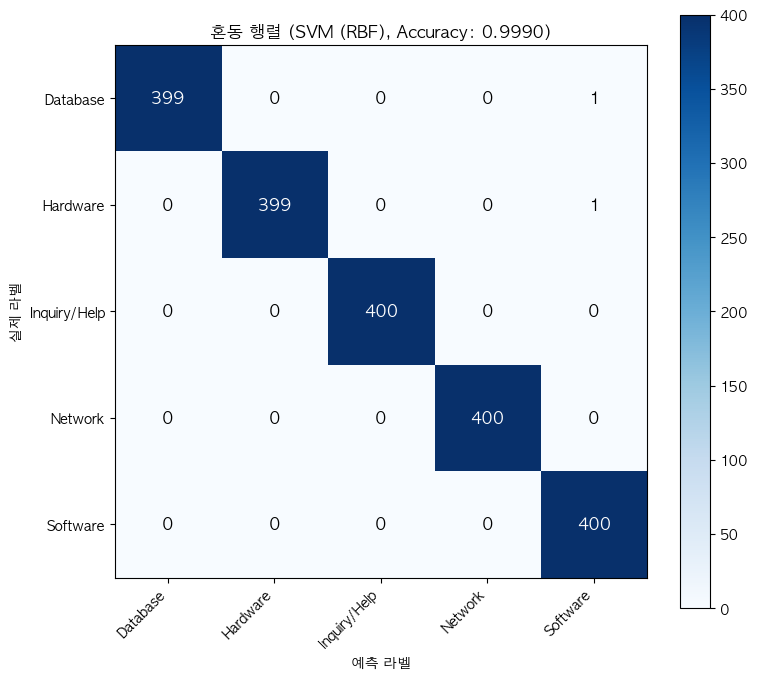


카테고리별 정확도:
  Database       : 399/400 (99.8%)
  Hardware       : 399/400 (99.8%)
  Inquiry/Help   : 400/400 (100.0%)
  Network        : 400/400 (100.0%)
  Software       : 400/400 (100.0%)


In [9]:
# =============================================================================
# 9. 혼동 행렬 시각화
# =============================================================================
# [의도] 분류기의 예측 결과를 5x5 행렬로 시각화하여
# 어떤 카테고리 간에 오분류가 발생하는지 직관적으로 파악합니다.
#
# [혼동 행렬 해석 - 다중 분류]
#   행(row) = 실제 라벨, 열(column) = 예측 라벨
#   대각선 원소: 올바른 분류 (실제 = 예측)
#   비대각선 원소: 오분류 (실제 != 예측)
#   예: (Hardware, Software) = 실제 Hardware를 Software로 잘못 분류한 건수
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib

# [한글 폰트 설정]
# matplotlib의 기본 폰트는 한글을 지원하지 않으므로,
# macOS의 AppleGothic 폰트를 지정하여 한글 깨짐을 방지합니다.
# unicode_minus=False로 마이너스 기호가 깨지는 문제도 해결합니다.
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# [혼동 행렬 계산]
cm = confusion_matrix(y_test, y_pred, labels=label_names)

# [히트맵 시각화]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=range(len(label_names)), yticks=range(len(label_names)),
       xticklabels=label_names, yticklabels=label_names,
       ylabel='실제 라벨', xlabel='예측 라벨',
       title=f'혼동 행렬 ({best_name}, Accuracy: {acc:.4f})')

# x축 라벨 회전: 카테고리 이름이 길어 겹치지 않도록 45도 회전합니다.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# [셀 안에 숫자 표시]
# 각 셀에 건수를 직접 표시하여 정확한 값을 확인할 수 있게 합니다.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=12)

plt.tight_layout()
plt.show()

# [카테고리별 정확도 요약]
print(f"\n카테고리별 정확도:")
for i, cat in enumerate(label_names):
    correct = cm[i, i]
    total = cm[i].sum()
    print(f"  {cat:15s}: {correct}/{total} ({correct/total*100:.1f}%)")

---
## Step 4: 예측 & 평가

In [10]:
# =============================================================================
# 10. 예측 함수 정의 (새로운 IT 문의의 담당 부서를 분류)
# =============================================================================
# [의도] 학습이 완료된 분류기를 사용하여 새로운 IT 문의 텍스트의
# 담당 부서(카테고리)를 예측하는 함수를 정의합니다.
#
# [핵심 포인트 - 전처리 일관성]
#   입력 텍스트에도 학습 데이터와 동일한 clean_text() 전처리를 적용합니다.
#   학습 시 전처리된 텍스트로 임베딩을 생성했으므로,
#   예측 시에도 같은 전처리를 거쳐야 임베딩 공간에서 올바른 위치에 매핑됩니다.
#
# [predict_proba의 역할]
#   일반 predict()는 가장 확률이 높은 클래스 하나만 반환하지만,
#   predict_proba()는 모든 클래스에 대한 확률 분포를 반환합니다.
#   5개 카테고리에 대한 확률을 보여주어 분류기의 "확신 정도"를 파악할 수 있습니다.
# =============================================================================
def predict_category(text: str):
    """
    IT 문의 텍스트를 입력받아 담당 부서(카테고리)를 예측합니다.
    
    [처리 흐름]
    1) clean_text()로 입력 텍스트 전처리
    2) 임베딩 모델로 벡터 변환
    3) 분류기로 5개 카테고리 확률 계산
    4) 결과를 막대 그래프로 시각화
    
    Args:
        text: 분류할 IT 문의 텍스트 (원본 그대로 입력)
    """
    # 입력 텍스트에 학습 데이터와 동일한 전처리를 적용합니다.
    cleaned = clean_text(text)
    
    # 전처리된 텍스트를 768차원 벡터로 변환합니다.
    emb = model.encode([cleaned], convert_to_numpy=True)
    
    # 분류기를 통해 각 카테고리에 속할 확률을 계산합니다.
    probs = clf.predict_proba(emb)[0]
    
    # 가장 확률이 높은 카테고리를 예측 결과로 선택합니다.
    pred_idx = np.argmax(probs)
    pred_category = clf.classes_[pred_idx]

    # [결과 출력]
    print("\n" + "=" * 60)
    print(" 문의 내용:")
    print(f"   {text}")
    if cleaned != text:
        print(f"   (전처리 후: {cleaned[:60]}{'...' if len(cleaned)>60 else ''})")
    print("=" * 60)
    
    # 카테고리별 확률을 시각적 막대 그래프로 출력합니다.
    # 확률 순으로 정렬하여 가장 높은 카테고리가 위에 오게 합니다.
    print(f"\n 예측 결과: [{pred_category}]")
    sorted_indices = np.argsort(probs)[::-1]  # 내림차순 정렬
    for idx in sorted_indices:
        cat = clf.classes_[idx]
        p = probs[idx]
        bar = "█" * int(p * 30)
        marker = " <--" if idx == pred_idx else ""
        print(f"   {cat:15s} {bar} ({p:.3f}){marker}")
    print("=" * 60 + "\n")

In [11]:
# =============================================================================
# 테스트: 각 카테고리별 명확한 문의 5건으로 분류기 동작 확인
# =============================================================================
# [의도] 각 카테고리에 해당하는 명확한 문의를 입력하여
# 분류기가 올바르게 작동하는지 기본적인 검증을 수행합니다.
#
# [테스트 케이스 선정 기준]
# 각 부서에 해당하는 전형적인 IT 문의를 선택하여,
# 분류기가 5개 카테고리를 정확히 구분하는지 확인합니다.
# =============================================================================

# 테스트 1: Hardware
print(">>> 테스트 1: Hardware")
predict_category("컴퓨터가 부팅이 안 되고 팬 소리만 크게 나요. CPU 과열 같은데 확인 좀 해주세요.")

# 테스트 2: Software
print(">>> 테스트 2: Software")
predict_category("윈도우 업데이트 후 프로그램이 실행이 안 돼요. 호환성 문제인 것 같습니다.")

# 테스트 3: Network
print(">>> 테스트 3: Network")
predict_category("VPN 연결이 자꾸 끊겨서 재택근무가 안 됩니다. 오류 코드 800이 떠요.")

# 테스트 4: Database
print(">>> 테스트 4: Database")
predict_category("Oracle DB 쿼리 실행 속도가 갑자기 느려졌어요. 인덱스 점검 부탁드립니다.")

# 테스트 5: Inquiry/Help
print(">>> 테스트 5: Inquiry/Help")
predict_category("백신 프로그램 라이선스가 만료됐는데 갱신하려면 어떻게 해야 하나요?")

>>> 테스트 1: Hardware

 문의 내용:
   컴퓨터가 부팅이 안 되고 팬 소리만 크게 나요. CPU 과열 같은데 확인 좀 해주세요.

 예측 결과: [Hardware]
   Hardware        █████████████████████████████ (1.000) <--
   Network          (0.000)
   Software         (0.000)
   Inquiry/Help     (0.000)
   Database         (0.000)

>>> 테스트 2: Software

 문의 내용:
   윈도우 업데이트 후 프로그램이 실행이 안 돼요. 호환성 문제인 것 같습니다.

 예측 결과: [Software]
   Software        █████████████████████████████ (1.000) <--
   Inquiry/Help     (0.000)
   Hardware         (0.000)
   Database         (0.000)
   Network          (0.000)

>>> 테스트 3: Network

 문의 내용:
   VPN 연결이 자꾸 끊겨서 재택근무가 안 됩니다. 오류 코드 800이 떠요.

 예측 결과: [Network]
   Network         █████████████████████████████ (0.999) <--
   Software         (0.001)
   Database         (0.000)
   Inquiry/Help     (0.000)
   Hardware         (0.000)

>>> 테스트 4: Database

 문의 내용:
   Oracle DB 쿼리 실행 속도가 갑자기 느려졌어요. 인덱스 점검 부탁드립니다.

 예측 결과: [Database]
   Database        █████████████████████████████ (0.995) <--
   Hardware         (0.005)
  

---
## Step 5: 미니 미션

### 미션 1: 직접 IT 문의 작성하기
각 카테고리에 해당하는 IT 문의를 직접 작성하고, AI가 올바르게 분류하는지 확인하세요.

In [12]:
# =============================================================================
# 미션 1-1: Hardware 문의 작성
# =============================================================================
# [의도] 하드웨어 관련 문의를 직접 작성하여
# 분류기가 올바르게 "Hardware"로 판별하는지 확인합니다.
# =============================================================================
my_query_1 = "노트북 충전기를 꽂아도 충전이 안 됩니다. 배터리 교체가 필요한 건가요?"
predict_category(my_query_1)
# 예상한 카테고리: Hardware
# AI의 예측이 맞았나요?: 


 문의 내용:
   노트북 충전기를 꽂아도 충전이 안 됩니다. 배터리 교체가 필요한 건가요?

 예측 결과: [Hardware]
   Hardware        ████████████████████ (0.692) <--
   Network         ███████ (0.242)
   Inquiry/Help    █ (0.047)
   Software         (0.009)
   Database         (0.009)



In [13]:
# =============================================================================
# 미션 1-2: Network 문의 작성
# =============================================================================
# [의도] 네트워크 관련 문의를 작성하여 분류기를 테스트합니다.
# Hardware와 혼동될 수 있는 네트워크 장비 문제도 포함해 봅니다.
# =============================================================================
my_query_2 = "회의실 와이파이가 연결은 되는데 인터넷이 안 돼요. 다른 기기도 마찬가지입니다."
predict_category(my_query_2)
# 예상한 카테고리: Network
# AI의 예측이 맞았나요?: 


 문의 내용:
   회의실 와이파이가 연결은 되는데 인터넷이 안 돼요. 다른 기기도 마찬가지입니다.

 예측 결과: [Network]
   Network         █████████████████████████████ (1.000) <--
   Software         (0.000)
   Hardware         (0.000)
   Inquiry/Help     (0.000)
   Database         (0.000)



In [14]:
# =============================================================================
# 미션 1-3: Database 문의 작성
# =============================================================================
# [의도] 데이터베이스 관련 문의를 작성하여 분류기를 테스트합니다.
# DB 관련 전문 용어가 포함된 문장이 올바르게 분류되는지 확인합니다.
# =============================================================================
my_query_3 = "운영 DB 백업이 실패했다는 알림이 떴습니다. 디스크 용량 문제인지 확인 부탁드립니다."
predict_category(my_query_3)
# 예상한 카테고리: Database
# AI의 예측이 맞았나요?: 


 문의 내용:
   운영 DB 백업이 실패했다는 알림이 떴습니다. 디스크 용량 문제인지 확인 부탁드립니다.

 예측 결과: [Database]
   Database        ███████████████████████ (0.776) <--
   Hardware        █████ (0.200)
   Software         (0.023)
   Network          (0.001)
   Inquiry/Help     (0.000)



### 미션 2: 경계가 애매한 문의 만들기
여러 카테고리에 **걸칠 수 있는** 문의를 만들어보세요.  
예: "이메일이 안 열리는데 네트워크 문제인가요, 소프트웨어 문제인가요?" -> Software? Network? Inquiry/Help?

In [15]:
# =============================================================================
# 미션 2-1: Hardware vs Network 경계 문의
# =============================================================================
# [의도] 하드웨어 장비와 네트워크가 동시에 언급되는 문의를 입력하여
# 분류기가 어떤 카테고리로 판단하는지 관찰합니다.
# =============================================================================
ambiguous_1 = "공유기를 새로 교체했는데 랜선을 꽂아도 인터넷이 안 잡혀요. 랜 포트 불량인가요?"
predict_category(ambiguous_1)
# 실제 적합한 카테고리: Hardware? Network?
# AI 예측이 적절한가요?: 


 문의 내용:
   공유기를 새로 교체했는데 랜선을 꽂아도 인터넷이 안 잡혀요. 랜 포트 불량인가요?

 예측 결과: [Network]
   Network         █████████████████████████████ (1.000) <--
   Software         (0.000)
   Hardware         (0.000)
   Inquiry/Help     (0.000)
   Database         (0.000)



In [16]:
# =============================================================================
# 미션 2-2: Software vs Database 경계 문의
# =============================================================================
# [의도] 소프트웨어와 데이터베이스가 동시에 관련된 문의를 테스트합니다.
# 애플리케이션에서 DB 접속 오류가 발생하는 경우,
# 소프트웨어 문제인지 데이터베이스 문제인지 판단이 어렵습니다.
# =============================================================================
ambiguous_2 = "사내 ERP 프로그램에서 데이터 조회가 안 되는데 DB 서버가 다운된 건가요?"
predict_category(ambiguous_2)
# 실제 적합한 카테고리: Software? Database?
# AI 예측이 적절한가요?: 


 문의 내용:
   사내 ERP 프로그램에서 데이터 조회가 안 되는데 DB 서버가 다운된 건가요?

 예측 결과: [Inquiry/Help]
   Inquiry/Help    ████████████████████████ (0.815) <--
   Database        ████ (0.136)
   Hardware         (0.033)
   Software         (0.014)
   Network          (0.002)



In [17]:
# =============================================================================
# 미션 2-3: 여러 카테고리에 걸치는 복합 문의
# =============================================================================
# [의도] 세 가지 이상의 카테고리가 동시에 언급되는 복합적인 문의를 테스트합니다.
# 실제 IT 헬프데스크에서는 이런 복합 문의가 자주 발생합니다.
# =============================================================================
ambiguous_3 = "이메일로 받은 파일을 열려고 하니 백신에서 차단하고, 컴퓨터도 갑자기 느려졌어요."
predict_category(ambiguous_3)
# 실제 적합한 카테고리: Software? Inquiry/Help? Hardware?
# AI 예측이 적절한가요?: 


 문의 내용:
   이메일로 받은 파일을 열려고 하니 백신에서 차단하고, 컴퓨터도 갑자기 느려졌어요.

 예측 결과: [Inquiry/Help]
   Inquiry/Help    █████████████████████████████ (1.000) <--
   Software         (0.000)
   Network          (0.000)
   Hardware         (0.000)
   Database         (0.000)



### 미션 3: AI 확신도 분석
`predict_category`는 5개 카테고리별 확률을 보여줍니다.

- 한 카테고리 확률이 0.7 이상 -> AI가 **확신**하는 것
- 상위 2개 카테고리 확률이 비슷 -> AI가 **헷갈리는** 것

이 두 가지 경우를 각각 찾아보세요.

In [18]:
# =============================================================================
# 미션 3-1: AI가 확신하는 문의 (한 카테고리 확률 0.7 이상 목표)
# =============================================================================
# [의도] 분류기가 높은 확신을 가지는 문의를 작성합니다.
# 특정 카테고리에만 해당하는 명확한 키워드가 포함된
# 문장일수록 확신도가 높아집니다.
# =============================================================================
certain_query = "키보드 '아'키가 눌리지 않아요. 다른 키보드로 교체해주세요."
predict_category(certain_query)
# 가장 높은 카테고리 확률: 


 문의 내용:
   키보드 '아'키가 눌리지 않아요. 다른 키보드로 교체해주세요.

 예측 결과: [Hardware]
   Hardware        █████████████████████████████ (1.000) <--
   Software         (0.000)
   Network          (0.000)
   Inquiry/Help     (0.000)
   Database         (0.000)



In [19]:
# =============================================================================
# 미션 3-2: AI가 헷갈리는 문의 (상위 2개 카테고리 확률 차이 0.1 이하 목표)
# =============================================================================
# [의도] 분류기가 확신하지 못하는 문의를 작성합니다.
# 여러 카테고리에 걸치는 내용을 포함하여 한쪽으로 결정하기 어려운 문장이
# 대표적인 예시입니다.
# 이런 경우가 실무에서 발생하면 사람이 최종 판단해야 합니다.
# =============================================================================
uncertain_query = "컴퓨터가 느려서 프로그램도 안 열리고 인터넷도 끊기는데 원인을 모르겠어요."
predict_category(uncertain_query)
# 상위 2개 카테고리 확률 차이: 


 문의 내용:
   컴퓨터가 느려서 프로그램도 안 열리고 인터넷도 끊기는데 원인을 모르겠어요.

 예측 결과: [Hardware]
   Hardware        ██████████████ (0.479) <--
   Network         ████████████ (0.430)
   Inquiry/Help    ██ (0.076)
   Software         (0.011)
   Database         (0.004)



### 미션 4: 실제 업무 활용 아이디어
이 IT 요청 분류기를 실제 IT 헬프데스크에 적용한다면 어떻게 활용할 수 있을까요?

In [20]:
# =============================================================================
# 미션 4: 실제 업무 활용 아이디어
# =============================================================================
# [의도] 기술적 구현을 넘어, 이 IT 요청 분류기가 실제 비즈니스 환경에서
# 어떻게 활용될 수 있는지 생각해보는 확장 과제입니다.
# 기술의 한계와 가능성을 함께 고려하여 현실적인 활용 방안을 모색합니다.
# =============================================================================
#
# 1. 이 분류기를 IT 헬프데스크에 적용하면 어떤 점이 좋을까요?
#    -> 
#
# 2. 분류 정확도를 높이려면 어떤 방법이 있을까요? (2가지 이상)
#    -> 
#
# 3. 5개 카테고리 외에 추가하면 좋을 카테고리가 있다면?
#    -> 
#
# 4. 이 분류기의 한계점은 무엇일까요?
#    -> 